### Goal:
#### Explore the Coffee Sales Trends dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

#### 1. Why This Project?
##### 1.Learn data cleaning with Pandas.
 
##### 2.Use NumPy for calculations (mean, median, etc.).
 
##### 3.Visualize trends using Matplotlib and Seaborn.
 
##### 4.Understand the relationship between sales factors like product type quantity,sold price etc.

### 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

### 3. Load Dataset

In [6]:
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\Coffe_sales (4).csv")
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


### 4. Explore Data

In [7]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.columns.tolist())

Shape: (3547, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB
None
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64
       hour_of_day        money  Weekdaysort    Monthsort
co

### 5. Data Cleaning

In [8]:
for col in ['Quantity', 'Sales', 'Unit Price']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
for col in ['Product', 'Region', 'Customer']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

if 'Date' in df.columns:
    df = df.dropna(subset=['Date'])

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


### Insights:
 
1.Missing values were filled or removed.

2.Duplicates were dropped.

3.Data was ready for visualization and statistical analysis.

### 6. Analysis with NumPy & Pandas

In [14]:
# Total sales
total_sales = df['money'].sum()
print(f"💰 Total Sales: ₹{total_sales:.2f}")

# Average transaction amount
avg_sale = df['money'].mean()
print(f"📦 Average Sale: ₹{avg_sale:.2f}")

# Number of transactions
print(f"🧾 Total Transactions: {len(df)}")


top_coffee = df['coffee_name'].value_counts().head(5)
print(top_coffee)



💰 Total Sales: ₹112245.58
📦 Average Sale: ₹31.65
🧾 Total Transactions: 3547
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Name: count, dtype: int64


### Insights:

1.The Total Sales: ₹112245.58

2.Americano variants dominate — together they form over 38% of total sales.

3.Latte is a close competitor, suggesting high demand for smooth, milk-based drinks.

4.Cortado, being least ordered, might either be niche or under-promoted.

### 7. Visualization with Matplotlib

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\1785120678.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\1785120678.py:16: UserWarning: Glyph 9749 (\N{HOT BEVERAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9749 (\N{HOT BEVERAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


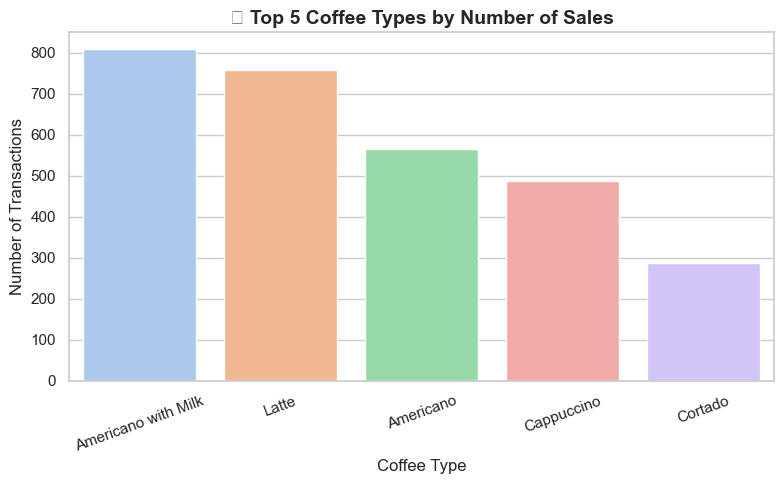

In [17]:
coffee_counts = df['coffee_name'].value_counts().head(5)

# bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x=coffee_counts.index,
    y=coffee_counts.values,
    palette="pastel"
)

# Chart labels and title
plt.title("☕ Top 5 Coffee Types by Number of Sales", fontsize=14, weight='bold')
plt.xlabel("Coffee Type", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### Insights:
 
Milk-based coffees dominate — Americano with Milk and Latte together account for over 40% of total sales.

Cortado has significantly fewer orders (287), less than half of the top performer.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\2935301121.py:12: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


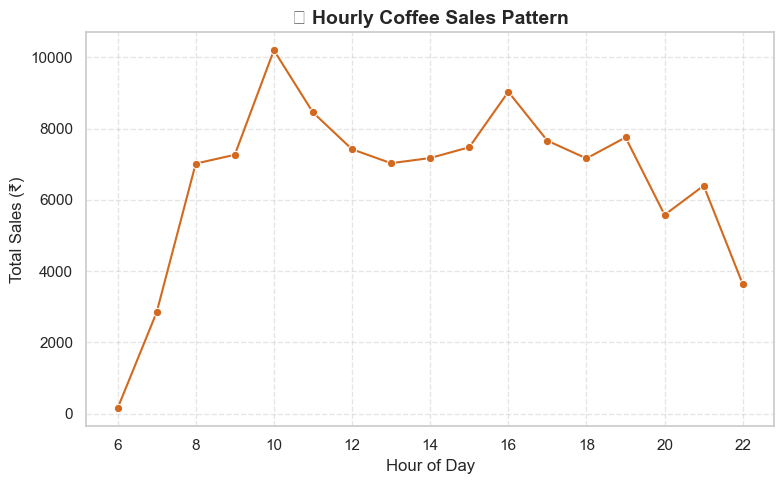

In [21]:
# Group by hour and sum sales
hourly_sales = df.groupby('hour_of_day')['money'].sum()

# Line Plot
plt.figure(figsize=(8,5))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', color='chocolate')

plt.title("🕒 Hourly Coffee Sales Pattern", fontsize=14, weight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Sales (₹)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Insights:
 
1.Expect morning (8–11 AM) and afternoon (12–3 PM) peaks.

2.Helps identify best hours for promotions or staffing.

### 8. Visualization with Seaborn

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\176013783.py:8: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


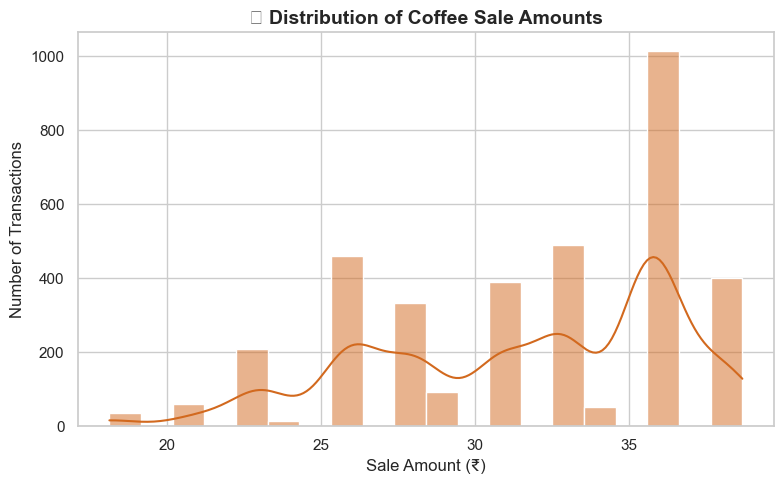

In [20]:
## Histogram for coffee sales 
plt.figure(figsize=(8,5))
sns.histplot(df['money'], bins=20, kde=True, color='chocolate')

plt.title("💰 Distribution of Coffee Sale Amounts", fontsize=14, weight='bold')
plt.xlabel("Sale Amount (₹)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.tight_layout()
plt.show()

### Insights:
 
1.A right-skewed distribution (long tail to the right) means some higher-value combo sales.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\2926551255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='coffee_name', data=df, palette='pastel')
C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\2926551255.py:12: UserWarning: Glyph 9749 (\N{HOT BEVERAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9749 (\N{HOT BEVERAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


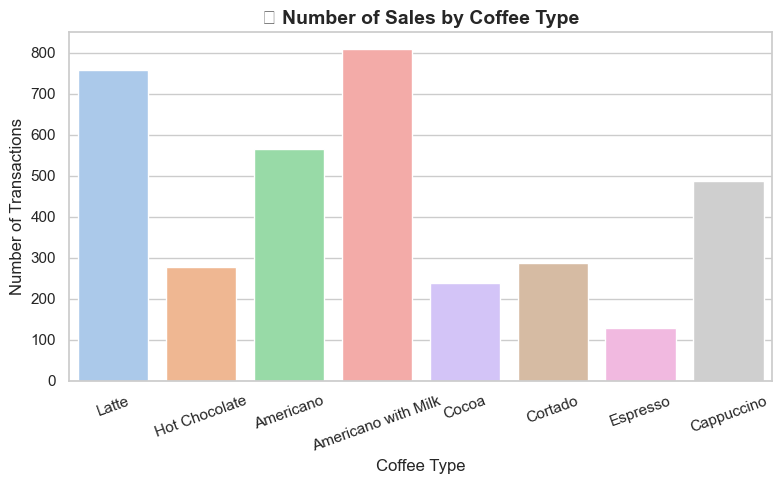

In [ ]:
#Count plot 

plt.figure(figsize=(8,5))
sns.countplot(x='coffee_name', data=df, palette='pastel')

plt.title("☕ Number of Sales by Coffee Type", fontsize=14, weight='bold')
plt.xlabel("Coffee Type", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### Insights:
 
1.Quickly shows the most and least popular coffees.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_14612\263080851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Time_of_Day', y='money', data=df, palette='pastel')
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


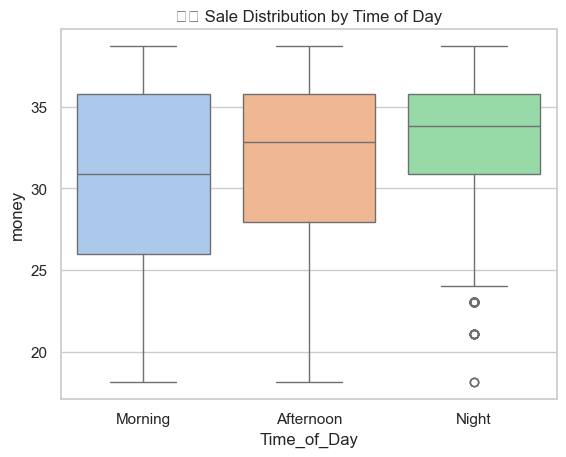

In [29]:
# Box Plot for Sales by Coffee Type
sns.boxplot(x='Time_of_Day', y='money', data=df, palette='pastel')
plt.title("☀️ Sale Distribution by Time of Day")
plt.show()


#### Insights:
 
Helps you see when people spend more — e.g., higher bills during afternoon breaks.

c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


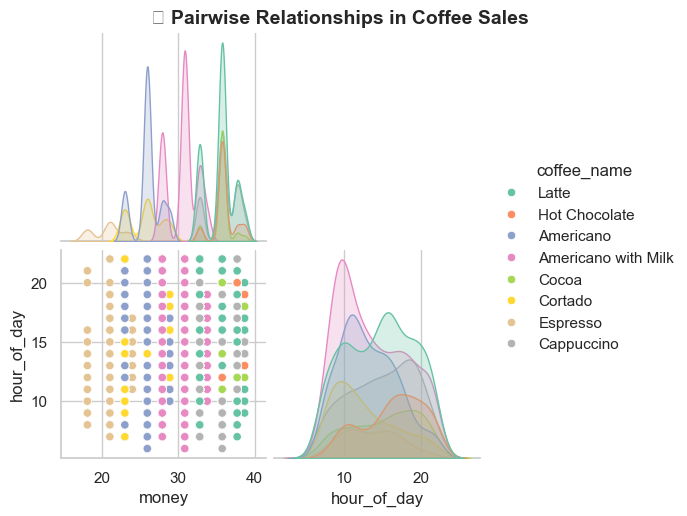

In [32]:
numeric_cols = ['money', 'hour_of_day',]

# Optional: Add coffee_name as hue to see different coffee types in different colors
sns.pairplot(df[numeric_cols + ['coffee_name']], 
             hue='coffee_name', 
             diag_kind='kde',   # KDE instead of histogram on diagonal
             palette='Set2',    # nice pastel colors
             corner=True)       # only lower triangle to avoid duplication

plt.suptitle("📊 Pairwise Relationships in Coffee Sales", y=1.02, fontsize=14, weight='bold')
plt.show()

### Insights:
 
hour_of_day vs money might show that afternoon sales are slightly higher.

c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


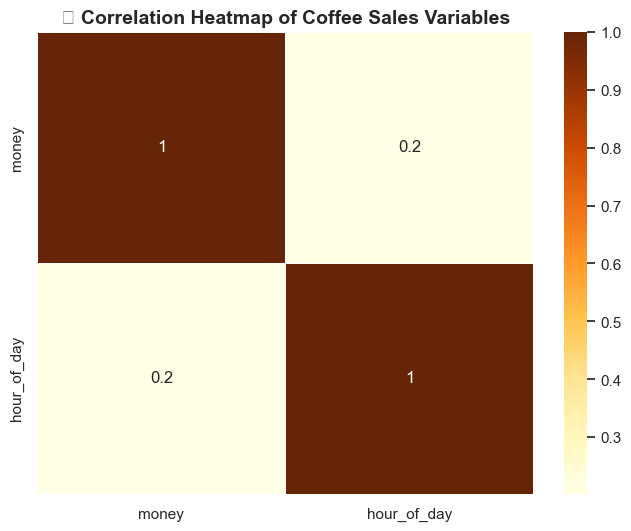

In [34]:
# Heatmap
# Select numeric columns
numeric_cols = ['money', 'hour_of_day']

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrBr', linewidths=0.5)

plt.title("📊 Correlation Heatmap of Coffee Sales Variables", fontsize=14, weight='bold')
plt.show()

### Insights:
 
Positive correlation between hour_of_day and money → afternoon sales may be higher.